In [13]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [14]:
url = "https://www.realtor.com/local/market/indiana"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")
tables = pd.read_html(str(soup))

print("Number of tables found:", len(tables))

for i, table in enumerate(tables):
    print("\nTABLE", i)
    print(table.head())

Number of tables found: 8

TABLE 0
                  Metric   Statewide 1Y Change 3Y Change
0       Median listing $    $279,727     1.76%        8%
1            $ per sq ft  $158/sq ft     4.64%    15.33%
2        Active listings       31827     8.72%    34.10%
3  Median days on market     53 days        6%    76.67%
4      Rental properties        7538    44.73%    21.94%

TABLE 1
           City Median listing price Listing $ / sq ft  \
0  Indianapolis             $254,500              $156   
1    Fort Wayne             $277,000              $155   
2    Evansville             $189,900              $131   
3    South Bend             $225,000              $147   
4   Bloomington             $360,000              $193   

  Median monthly rental price  
0                  $1,595 /mo  
1                  $1,297 /mo  
2                  $1,300 /mo  
3                  $1,275 /mo  
4                  $1,822 /mo  

TABLE 2
  Unnamed: 0_level_0 Homes for sale          Properties for rent

/tmp/ipykernel_9039/1792074332.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(str(soup))


In [16]:
def clean_money(series):
    return (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("/mo", "", regex=False)
        .str.replace("/sq ft", "", regex=False)
        .str.strip()
        .replace("–", pd.NA)
        .replace("-", pd.NA)
    )

def clean_number(series):
    return pd.to_numeric(clean_money(series), errors="coerce")

def clean_percent(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("–", pd.NA)
        .replace("-", pd.NA),
        errors="coerce"
    )

def clean_days(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace("days", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

In [22]:
statewide_df = None
city_df = None
county_price_df = None
county_inventory_df = None
county_days_df = None

for table in tables:
    # Get column names, handling MultiIndex by getting the lowest level
    current_table_columns = []
    if isinstance(table.columns, pd.MultiIndex):
        current_table_columns = table.columns.get_level_values(-1).tolist()
    else:
        current_table_columns = table.columns.tolist()

    # Clean the column names for comparison
    cols = [str(c).strip() for c in current_table_columns]

    if cols == ["Metric", "Statewide", "1Y Change", "3Y Change"]:
        statewide_df = table.copy()

    elif len(cols) >= 4 and cols[0] == "City" and "Listing $ / sq ft" in cols:
        city_df = table.copy()

    elif len(cols) >= 4 and cols[0] == "County" and "Listing $ / sq ft" in cols:
        county_price_df = table.copy()

    elif len(cols) >= 5 and cols[0] == "County" and "For sale" in cols and "For rent" in cols:
        county_inventory_df = table.copy()

    elif len(cols) >= 3 and cols[0] == "County" and "Days" in cols:
        county_days_df = table.copy()

print("statewide_df found:", statewide_df is not None)
print("city_df found:", city_df is not None)
print("county_price_df found:", county_price_df is not None)
print("county_inventory_df found:", county_inventory_df is not None)
print("county_days_df found:", county_days_df is not None)

statewide_df found: True
city_df found: True
county_price_df found: True
county_inventory_df found: True
county_days_df found: True


In [18]:
statewide_df.columns = ["Metric", "Statewide", "1Y Change", "3Y Change"]

statewide_clean = statewide_df.copy()

statewide_clean["Statewide"] = statewide_clean["Statewide"].astype(str)
statewide_clean["1Y Change"] = clean_percent(statewide_clean["1Y Change"])
statewide_clean["3Y Change"] = clean_percent(statewide_clean["3Y Change"])

statewide_clean

,Metric,Statewide,1Y Change,3Y Change
0,Median listing $,"$279,727",1.76,8.00
1,$ per sq ft,$158/sq ft,4.64,15.33
2,Active listings,31827,8.72,34.10
3,Median days on market,53 days,6.00,76.67
4,Rental properties,7538,44.73,21.94
5,Median rent,"$1,464/mo",-11.27,4.57


In [19]:
city_df.columns = ["City", "Median Listing Price", "Listing Price Per SqFt", "Median Monthly Rent"]

city_clean = city_df.copy()
city_clean["Median Listing Price"] = clean_number(city_clean["Median Listing Price"])
city_clean["Listing Price Per SqFt"] = clean_number(city_clean["Listing Price Per SqFt"])
city_clean["Median Monthly Rent"] = clean_number(city_clean["Median Monthly Rent"])

city_clean

,City,Median Listing Price,Listing Price Per SqFt,Median Monthly Rent
0,Indianapolis,254500,156,1595
1,Fort Wayne,277000,155,1297
2,Evansville,189900,131,1300
3,South Bend,225000,147,1275
4,Bloomington,360000,193,1822
5,Lakes Of Four Seasons,384995,184,1611
6,Westfield,494497,204,2450
7,Noblesville,416390,176,2100
8,Greenwood,350000,168,1895
9,Crown Point,379400,178,1601


In [20]:
county_price_df.columns = ["County", "Median Listing Price", "Listing Price Per SqFt", "Median Monthly Rent"]

county_price_clean = county_price_df.copy()
county_price_clean["Median Listing Price"] = clean_number(county_price_clean["Median Listing Price"])
county_price_clean["Listing Price Per SqFt"] = clean_number(county_price_clean["Listing Price Per SqFt"])
county_price_clean["Median Monthly Rent"] = clean_number(county_price_clean["Median Monthly Rent"])

county_price_clean

,County,Median Listing Price,Listing Price Per SqFt,Median Monthly Rent
0,Marion County,250000,156,1580
1,Lake County,279900,163,1476
2,Hamilton County,465000,192,2377
3,Allen County,299900,161,1300
4,St. Joseph County,267000,155,1267
5,Hendricks County,364900,165,2000
6,Clark County,279000,175,1700
7,Johnson County,339900,171,1860
8,Porter County,375000,178,1375
9,Vanderburgh County,189900,131,1300


In [23]:
county_inventory_df.columns = ["County", "For Sale", "For Sale YoY %", "For Rent", "For Rent MoM %"]

county_inventory_clean = county_inventory_df.copy()
county_inventory_clean["For Sale"] = clean_number(county_inventory_clean["For Sale"])
county_inventory_clean["For Sale YoY %"] = clean_percent(county_inventory_clean["For Sale YoY %"])
county_inventory_clean["For Rent"] = clean_number(county_inventory_clean["For Rent"])
county_inventory_clean["For Rent MoM %"] = clean_percent(county_inventory_clean["For Rent MoM %"])

county_inventory_clean

,County,For Sale,For Sale YoY %,For Rent,For Rent MoM %
0,Marion County,4220,14.45,1822,-2.69
1,Lake County,2508,5.46,713,7.69
2,Hamilton County,1912,22.99,347,-3.14
3,Allen County,1681,4.07,397,-3.14
4,St. Joseph County,1212,-14.86,196,20.00
5,Hendricks County,1019,14.85,144,20.65
6,Clark County,967,19.92,101,-6.25
7,Johnson County,948,14.24,143,-3.31
8,Porter County,947,-10.77,242,-6.23
9,Vanderburgh County,842,11.19,189,0.00


In [24]:
county_days_df.columns = ["County", "Days on Market", "MoM %", "YoY %"]

county_days_clean = county_days_df.copy()
county_days_clean["Days on Market"] = clean_days(county_days_clean["Days on Market"])
county_days_clean["MoM %"] = clean_percent(county_days_clean["MoM %"])
county_days_clean["YoY %"] = clean_percent(county_days_clean["YoY %"])

county_days_clean

,County,Days on Market,MoM %,YoY %
0,DeKalb County,29,-39.58,-12.12
1,Whitley County,30,-50.00,-14.29
2,Tippecanoe County,33,-50.75,6.45
3,Montgomery County,37,-33.93,-28.85
4,LaGrange County,40,-53.49,-33.33
5,Adams County,44,-35.29,100.00
6,Hamilton County,44,-35.29,41.94
7,St. Joseph County,44,-24.14,-12.00
8,Howard County,45,-44.44,12.50
9,Allen County,46,-20.69,4.55


In [25]:
county_full = county_price_clean.merge(county_inventory_clean, on="County", how="left")
county_full = county_full.merge(county_days_clean, on="County", how="left")

county_full

,County,Median Listing Price,Listing Price Per SqFt,Median Monthly Rent,For Sale,For Sale YoY %,For Rent,For Rent MoM %,Days on Market,MoM %,YoY %
0,Marion County,250000,156,1580,4220,14.45,1822,-2.69,NaN,NaN,NaN
1,Lake County,279900,163,1476,2508,5.46,713,7.69,NaN,NaN,NaN
2,Hamilton County,465000,192,2377,1912,22.99,347,-3.14,44.0,-35.29,41.94
3,Allen County,299900,161,1300,1681,4.07,397,-3.14,46.0,-20.69,4.55
4,St. Joseph County,267000,155,1267,1212,-14.86,196,20.00,44.0,-24.14,-12.00
5,Hendricks County,364900,165,2000,1019,14.85,144,20.65,NaN,NaN,NaN
6,Clark County,279000,175,1700,967,19.92,101,-6.25,46.0,-11.54,15.00
7,Johnson County,339900,171,1860,948,14.24,143,-3.31,NaN,NaN,NaN
8,Porter County,375000,178,1375,947,-10.77,242,-6.23,NaN,NaN,NaN
9,Vanderburgh County,189900,131,1300,842,11.19,189,0.00,NaN,NaN,NaN


In [26]:
county_full.sort_values("Listing Price Per SqFt", ascending=False)

,County,Median Listing Price,Listing Price Per SqFt,Median Monthly Rent,For Sale,For Sale YoY %,For Rent,For Rent MoM %,Days on Market,MoM %,YoY %
11,Monroe County,359950,194,1800,747,22.03,781,5.49,NaN,NaN,NaN
2,Hamilton County,465000,192,2377,1912,22.99,347,-3.14,44.0,-35.29,41.94
8,Porter County,375000,178,1375,947,-10.77,242,-6.23,NaN,NaN,NaN
6,Clark County,279000,175,1700,967,19.92,101,-6.25,46.0,-11.54,15.00
7,Johnson County,339900,171,1860,948,14.24,143,-3.31,NaN,NaN,NaN
5,Hendricks County,364900,165,2000,1019,14.85,144,20.65,NaN,NaN,NaN
1,Lake County,279900,163,1476,2508,5.46,713,7.69,NaN,NaN,NaN
10,Hancock County,333945,163,1910,839,31.61,95,-1.39,NaN,NaN,NaN
3,Allen County,299900,161,1300,1681,4.07,397,-3.14,46.0,-20.69,4.55
13,LaPorte County,262000,158,1300,559,-5.94,132,-19.08,NaN,NaN,NaN


In [27]:
city_clean.sort_values("Listing Price Per SqFt", ascending=False)

,City,Median Listing Price,Listing Price Per SqFt,Median Monthly Rent
6,Westfield,494497,204,2450
4,Bloomington,360000,193,1822
5,Lakes Of Four Seasons,384995,184,1611
14,Jeffersonville,269950,182,1895
9,Crown Point,379400,178,1601
10,Valparaiso,399999,178,1329
11,Fishers,425000,178,2345
7,Noblesville,416390,176,2100
8,Greenwood,350000,168,1895
0,Indianapolis,254500,156,1595


In [28]:
statewide_clean.to_csv("indiana_statewide_market.csv", index=False)
city_clean.to_csv("indiana_city_market.csv", index=False)
county_price_clean.to_csv("indiana_county_prices.csv", index=False)
county_inventory_clean.to_csv("indiana_county_inventory.csv", index=False)
county_days_clean.to_csv("indiana_county_days_on_market.csv", index=False)
county_full.to_csv("indiana_county_full_market.csv", index=False)

print("CSV files saved.")

CSV files saved.


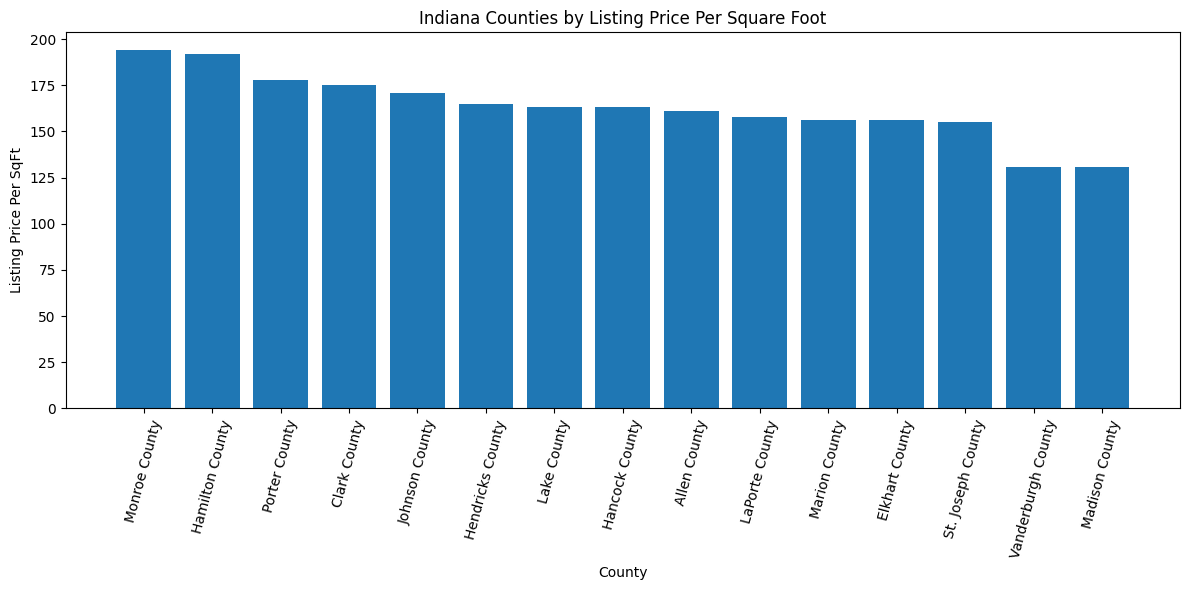

In [29]:
import matplotlib.pyplot as plt

plot_df = county_full.sort_values("Listing Price Per SqFt", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["County"], plot_df["Listing Price Per SqFt"])
plt.xticks(rotation=75)
plt.xlabel("County")
plt.ylabel("Listing Price Per SqFt")
plt.title("Indiana Counties by Listing Price Per Square Foot")
plt.tight_layout()
plt.show()

In [30]:
statewide_clean.to_csv("indiana_statewide_market.csv", index=False)
city_clean.to_csv("indiana_city_market.csv", index=False)
county_full.to_csv("indiana_county_full_market.csv", index=False)